# __EDA__

In [3]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

| Paso | Objetivo |
|---:|---|
| 1 | Caracterizar el dataset (n de FDS, fabricantes, usos, rango de fechas) y verificar estructura básica de variables. |
| 2 | Medir **completitud**: identificar qué ítems/secciones están **PRESENTE/AUSENTE** y cuantificar variabilidad por FDS. |
| 3 | Medir **calidad/confiabilidad**: distribuir `NO_CONFIABLE/CONFI_RESTR/CONFIABLE`, calcular scores globales y por sección. |
| 4 | Evaluar **consistencia interna**: correlación entre secciones y detección de **brechas** (p. ej., Sección 2 alta vs Sección 8 baja). |
| 5 | Identificar **patrones de co-ocurrencia**: reglas de asociación (Apriori) sobre fallas de completitud y/o calidad. |
| 6 | Realizar **segmentación**: comparar desempeño por `USO`, `FABRICANTE` y tiempo; perfilar secciones donde se diferencian. |
| 7 | Construir **síntesis ejecutiva**: ranking por sección con índice combinado (completitud+calidad) y priorización de ítems. |
| 8 | Cerrar con **contrastes estadísticos y reportabilidad**: pruebas no paramétricas, tamaños de efecto, tendencias temporales y exportables. |

In [4]:
df = pd.read_csv('../data/processed/eval.csv')

# estos ítems corresponden a sustancias. Todos los datos corresponden a mezclas
cols_to_set = [
    "ITEM_3_1_1", "CALIDAD_3_1_1",
    "ITEM_3_1_1_1", "CALIDAD_3_1_1_1",
    "ITEM_3_1_1_2", "CALIDAD_3_1_1_2",
    "ITEM_3_1_1_3", "CALIDAD_3_1_1_3",
]
df.drop(columns=cols_to_set, inplace=True, errors="ignore")

df.head()

,FDS,ELABORADA,ID,FABRICANTE,USO,ITEM_1_0,CALIDAD_1_0,ITEM_1_1,CALIDAD_1_1,ITEM_1_2,...,ITEM_14_6,CALIDAD_14_6,ITEM_15_0,CALIDAD_15_0,ITEM_15_1,CALIDAD_15_1,ITEM_16_0,CALIDAD_16_0,ITEM_16_1,CALIDAD_16_1
0,2,2020-09-20,F01-P01-I,F01,INDUSTRIAL,PRESENTE,NO_CONFIABLE,PRESENTE,CONFI_RESTR,PRESENTE,...,PRESENTE,CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,NO_CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,CONFI_RESTR
1,4,2020-02-28,F01-P02-I,F01,INDUSTRIAL,PRESENTE,NO_CONFIABLE,PRESENTE,CONFI_RESTR,PRESENTE,...,PRESENTE,CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,NO_CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,CONFI_RESTR
2,6,2020-02-28,F01-P03-I,F01,INDUSTRIAL,PRESENTE,NO_CONFIABLE,PRESENTE,CONFI_RESTR,PRESENTE,...,PRESENTE,CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,NO_CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,CONFI_RESTR
3,25,2020-01-04,F01-P04-I,F01,INDUSTRIAL,PRESENTE,NO_CONFIABLE,PRESENTE,CONFI_RESTR,PRESENTE,...,PRESENTE,CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,NO_CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,CONFI_RESTR
4,27,2020-06-05,F01-P05-I,F01,INDUSTRIAL,PRESENTE,NO_CONFIABLE,PRESENTE,CONFI_RESTR,PRESENTE,...,PRESENTE,CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,NO_CONFIABLE,PRESENTE,CONFIABLE,PRESENTE,CONFI_RESTR


## __PASO 1: Caracterizar FDS__

Caracterizar el dataset (n de FDS, fabricantes, usos, rango de fechas) y verificar estructura básica de variables. 

In [5]:
import re
import numpy as np
import pandas as pd

# 0.1 Columnas ITEM_ y CALIDAD_ (más estricto con regex, opcional)
item_cols = [c for c in df.columns if re.match(r"^ITEM_\d+(_\d+)*$", c)]
cal_cols  = [c for c in df.columns if re.match(r"^CALIDAD_\d+(_\d+)*$", c)]

# 0.2 Parseo de fecha + variables temporales
df["ELABORADA"] = pd.to_datetime(df["ELABORADA"], errors="coerce")
df["ANIO"] = df["ELABORADA"].dt.year
df["MES"]  = df["ELABORADA"].dt.month

# (Chequeo rápido de calidad del parseo)
df["ELABORADA_NAT"] = df["ELABORADA"].isna()

# 0.3 Mapeo calidad a ordinal (0-1-2) + coerción numérica segura
map_q = {"NO_CONFIABLE": 0, "CONFI_RESTR": 1, "CONFIABLE": 2}

q_num = df[cal_cols].replace(map_q)

# Si quedó algo no mapeado (texto), lo convierte a NaN
q_num = q_num.apply(pd.to_numeric, errors="coerce")

# (Chequeo: valores de calidad no contemplados)
valores_no_mapeados = (
    pd.Series(df[cal_cols].stack().dropna().unique())
      .loc[lambda s: ~s.isin(map_q.keys())]
      .tolist()
)

# 0.4 Score global (0–2 y 0–100) + trazabilidad
df["N_ITEMS_CALIDAD_VALIDOS"] = q_num.notna().sum(axis=1)
df["SCORE_GLOBAL_0_2"] = q_num.mean(axis=1, skipna=True)
df["SCORE_GLOBAL_0_100"] = (df["SCORE_GLOBAL_0_2"] / 2) * 100

In [8]:
import pandas as pd

# (Asumido) df, item_cols y cal_cols ya existen
df["ELABORADA"] = pd.to_datetime(df["ELABORADA"])

# ids ITEM/CALIDAD y pares
ids_item = {c[5:] for c in item_cols}      # quita "ITEM_"
ids_cal  = {c[8:] for c in cal_cols}       # quita "CALIDAD_"
n_pares  = len(ids_item & ids_cal)

# completitud por presencia
pct_pres = df[item_cols].eq("PRESENTE").mean(axis=1) * 100

# resumen (1 fila)
resumen = pd.DataFrame({
    "n_fds": [len(df)],
    "n_id_unicos": [df["ID"].nunique()],
    "n_fabricantes": [df["FABRICANTE"].nunique()],
    "n_usos": [df["USO"].nunique()],
    "fecha_min": [df["ELABORADA"].min()],
    "fecha_max": [df["ELABORADA"].max()],
    "items_total": [len(item_cols)],
    "calidades_total": [len(cal_cols)],
    "pct_items_presente_prom": [pct_pres.mean().round(1)],
    "pct_items_presente_mediana": [pct_pres.median().round(1)],
})

# scores (si existen)
for col in ["SCORE_GLOBAL_0_2", "SCORE_GLOBAL_0_100", "N_ITEMS_CALIDAD_VALIDOS"]:
    if col in df.columns:
        resumen[f"{col}_prom"] = df[col].mean()
        resumen[f"{col}_mediana"] = df[col].median()

# tablas de frecuencia
conteo_uso = (df["USO"].value_counts()
              .to_frame("conteo")
              .assign(porcentaje=lambda x: (x["conteo"]/len(df)*100).round(1)))

top_n = 15
fab_counts = df["FABRICANTE"].value_counts()
conteo_fab = (fab_counts.head(top_n)
              .to_frame("conteo")
              .assign(porcentaje=lambda x: (x["conteo"]/len(df)*100).round(1)))

# 1) Pasar resumen a formato largo (indicador - valor)
resumen_long = resumen.T.rename(columns={0: "valor"})
resumen_long.index.name = "indicador"

# 2) Diccionario de descripciones (cortas)
desc = {
    "n_fds": "Número total de FDS analizadas.",
    "n_id_unicos": "Cantidad de identificadores (ID) distintos.",
    "n_fabricantes": "Cantidad de fabricantes distintos.",
    "n_usos": "Cantidad de categorías de uso (p. ej., industrial/doméstico).",
    "fecha_min": "Fecha más antigua de elaboración registrada.",
    "fecha_max": "Fecha más reciente de elaboración registrada.",
    "items_total": "Número de ítems evaluados (columnas ITEM_*).",
    "calidades_total": "Número de calidades evaluadas (columnas CALIDAD_*).",

    "pct_items_presente_prom": "Promedio del % de ítems ITEM_* marcados como PRESENTE por FDS.",
    "pct_items_presente_mediana": "Mediana del % de ítems ITEM_* marcados como PRESENTE por FDS.",

    "SCORE_GLOBAL_0_2_prom": "Promedio del puntaje de calidad global en escala 0–2 (0,1,2).",
    "SCORE_GLOBAL_0_2_mediana": "Mediana del puntaje de calidad global en escala 0–2 (0,1,2).",
    "SCORE_GLOBAL_0_100_prom": "Promedio del puntaje de calidad global reescalado a 0–100.",
    "SCORE_GLOBAL_0_100_mediana": "Mediana del puntaje de calidad global reescalado a 0–100.",

    "N_ITEMS_CALIDAD_VALIDOS_prom": "Promedio de ítems con CALIDAD_* válida usados en el score (por FDS).",
    "N_ITEMS_CALIDAD_VALIDOS_mediana": "Mediana de ítems con CALIDAD_* válida usados en el score (por FDS).",
}

# 3) Agregar columna descripción
resumen_long["descripcion"] = resumen_long.index.map(desc).fillna("")

# 4) (Opcional) redondeos para presentación
resumen_long["valor"] = resumen_long["valor"].apply(
    lambda x: round(x, 4) if isinstance(x, float) else x
)

resumen_long

,valor,descripcion
indicador,,
n_fds,50,Número total de FDS analizadas.
n_id_unicos,50,Cantidad de identificadores (ID) distintos.
n_fabricantes,8,Cantidad de fabricantes distintos.
n_usos,2,"Cantidad de categorías de uso (p. ej., industr..."
fecha_min,2016-08-08 00:00:00,Fecha más antigua de elaboración registrada.
fecha_max,2020-10-07 00:00:00,Fecha más reciente de elaboración registrada.
items_total,71,Número de ítems evaluados (columnas ITEM_*).
calidades_total,71,Número de calidades evaluadas (columnas CALIDA...
pct_items_presente_prom,76.8,Promedio del % de ítems ITEM_* marcados como P...


/var/folders/t3/dd_m7b7x3nx7hlsr6x5zfm980000gn/T/ipykernel_12695/294060564.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box, labels=uso_labels, showmeans=True)


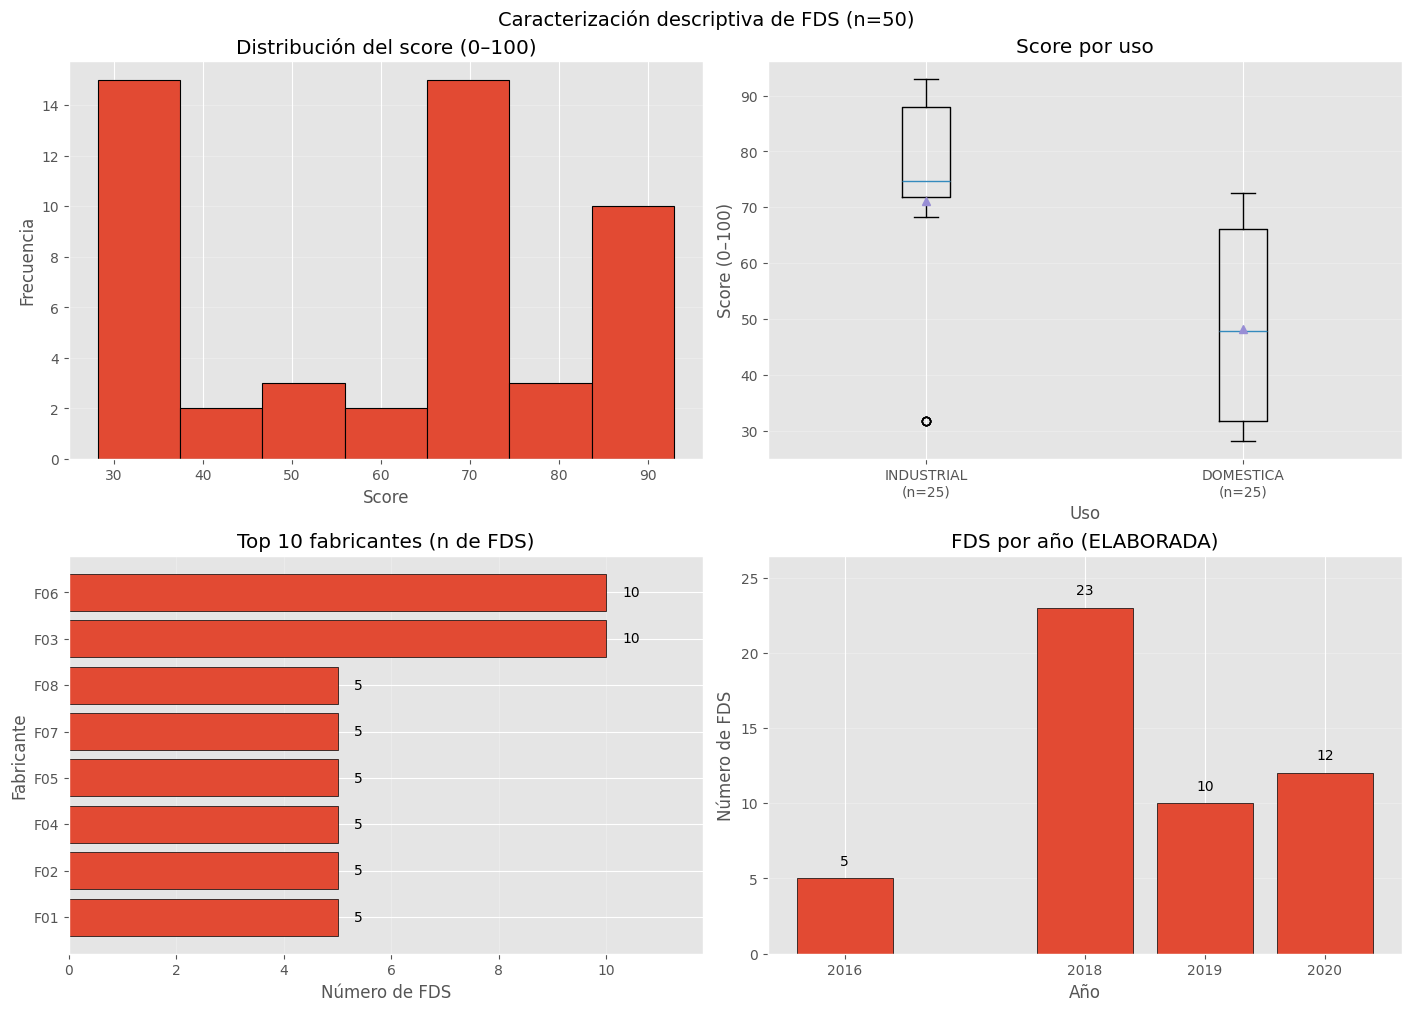

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("ggplot")

# --- Datos ---
score = df["SCORE_GLOBAL_0_100"].dropna()

uso_counts = df["USO"].value_counts()
uso_order = uso_counts.index.tolist()
data_box = [df.loc[df["USO"] == u, "SCORE_GLOBAL_0_100"].dropna().values for u in uso_order]
uso_labels = [f"{u}\n(n={uso_counts[u]})" for u in uso_order]

fab_counts = df["FABRICANTE"].value_counts().head(10).sort_values(ascending=True)

anio_counts = df["ANIO"].value_counts().sort_index()
anio_idx = anio_counts.index.astype(int)
anio_vals = anio_counts.values

# --- Figura 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle("Caracterización descriptiva de FDS (n=50)", fontsize=14)

# 1) Histograma SCORE
ax = axes[0, 0]
ax.hist(score, bins="auto", edgecolor="black", linewidth=0.8)
ax.set_title("Distribución del score (0–100)")
ax.set_xlabel("Score")
ax.set_ylabel("Frecuencia")
ax.grid(True, axis="y", alpha=0.25)

# 2) Boxplot SCORE por USO
ax = axes[0, 1]
ax.boxplot(data_box, labels=uso_labels, showmeans=True)
ax.set_title("Score por uso")
ax.set_xlabel("Uso")
ax.set_ylabel("Score (0–100)")
ax.grid(True, axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=0)

# 3) Barras horizontales: Top fabricantes
ax = axes[1, 0]
bars = ax.barh(fab_counts.index.astype(str), fab_counts.values, edgecolor="black")
ax.set_title("Top 10 fabricantes (n de FDS)")
ax.set_xlabel("Número de FDS")
ax.set_ylabel("Fabricante")
ax.grid(True, axis="x", alpha=0.25)

# Margen a la derecha para que quepan etiquetas
xmax = fab_counts.max() if len(fab_counts) else 0
ax.set_xlim(0, xmax * 1.18 if xmax else 1)

pad = max(0.03 * xmax, 0.2) if xmax else 0.2
for b in bars:
    w = b.get_width()
    ax.text(w + pad, b.get_y() + b.get_height()/2, f"{int(w)}", va="center")

# 4) Barras: FDS por año
ax = axes[1, 1]
bars = ax.bar(anio_idx, anio_vals, edgecolor="black")
ax.set_title("FDS por año (ELABORADA)")
ax.set_xlabel("Año")
ax.set_ylabel("Número de FDS")
ax.set_xticks(anio_idx)
ax.grid(True, axis="y", alpha=0.25)

ymax = anio_vals.max() if len(anio_vals) else 0
ax.set_ylim(0, ymax * 1.15 if ymax else 1)

ypad = max(0.03 * ymax, 0.2) if ymax else 0.2
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + ypad, f"{int(h)}",
            ha="center", va="bottom")

plt.show()

# Exportación recomendada para presentación
# fig.savefig("caracterizacion_fds_2x2.png", dpi=300, bbox_inches="tight")

In [12]:
conteo_uso

,conteo,porcentaje
USO,,
INDUSTRIAL,25,50.0
DOMESTICA,25,50.0


In [13]:
conteo_fab

,conteo,porcentaje
FABRICANTE,,
F03,10,20.0
F06,10,20.0
F01,5,10.0
F02,5,10.0
F04,5,10.0
F05,5,10.0
F07,5,10.0
F08,5,10.0


### __Paso 2: Completitud (PRESENTE/AUSENTE)__

Medir **completitud**: identificar qué ítems/secciones están **PRESENTE/AUSENTE** y cuantificar variabilidad por FDS. |


In [20]:
import re
import pandas as pd

# 1) % PRESENTE por ITEM (columnas ITEM_*)
item_presence = df[item_cols].eq("PRESENTE").mean().sort_values(ascending=True)

tabla_item_presence = pd.DataFrame({
    "prop_presente": item_presence,
})
tabla_item_presence["porc_presente"] = (tabla_item_presence["prop_presente"] * 100).round(1)
tabla_item_presence["porc_ausente"]  = (100 - tabla_item_presence["porc_presente"]).round(1)

top15_ausentes = tabla_item_presence.head(15)


# 2) Completitud promedio por SECCIÓN (1..16) usando el prefijo ITEM_{seccion}_...
def section_of_item(col):
    m = re.match(r"^ITEM_(\d+)_", col)  # captura 1,2,...,16 incluso 10,11...
    return int(m.group(1)) if m else None

item_to_section = {c: section_of_item(c) for c in item_cols}

sec_rows = []
for sec in sorted({s for s in item_to_section.values() if s is not None}):
    cols_sec = [c for c, s in item_to_section.items() if s == sec]
    # promedio por FDS dentro de la sección, luego promedio global
    porc_presente_prom = df[cols_sec].eq("PRESENTE").mean(axis=1).mean() * 100

    sec_rows.append({
        "seccion": sec,
        "n_items": len(cols_sec),
        "porc_presente_prom": round(porc_presente_prom, 1)
    })

tabla_seccion_presence = (
    pd.DataFrame(sec_rows)
      .sort_values("porc_presente_prom", ascending=True)
      .reset_index(drop=True)
)


# 3) Completitud por FDS (variabilidad entre FDS)
df["COMPLETITUD_FDS"] = df[item_cols].eq("PRESENTE").mean(axis=1) * 100

tabla_completitud_stats = df["COMPLETITUD_FDS"].describe().to_frame("valor")
tabla_completitud_stats.loc["IQR", "valor"] = (
    df["COMPLETITUD_FDS"].quantile(0.75) - df["COMPLETITUD_FDS"].quantile(0.25)
)
tabla_completitud_stats = tabla_completitud_stats.round(2)

tabla_item_presence["n_presentes"] = df[item_cols].eq("PRESENTE").sum(axis=0).loc[tabla_item_presence.index].astype(int)
tabla_item_presence["n_ausentes"]  = len(df) - tabla_item_presence["n_presentes"]

tabla_item_presence = tabla_item_presence.reset_index().rename(columns={"index":"col_item"})
tabla_item_presence["id"] = tabla_item_presence["col_item"].str.replace("^ITEM_", "", regex=True)

In [22]:
# 1) Resumen general de completitud por FDS (variabilidad)
print("=== Estadísticos de COMPLETITUD_FDS (%) ===")
print(tabla_completitud_stats)


=== Estadísticos de COMPLETITUD_FDS (%) ===
        valor
count   50.00
mean    76.76
std     18.62
min     47.89
25%     59.15
50%     85.92
75%     91.55
max    100.00
IQR     32.39


In [23]:
# 2) Secciones con menor/mayor presencia promedio
print("\n=== Presencia promedio por SECCIÓN (ordenado ascendente) ===")
print(tabla_seccion_presence)


=== Presencia promedio por SECCIÓN (ordenado ascendente) ===
    seccion  n_items  porc_presente_prom
0        11        6                56.0
1         3        5                68.4
2        14        7                71.1
3         6        4                71.5
4        12        6                71.7
5         2        7                72.6
6         7        3                76.7
7         5        4                77.0
8         1        6                81.0
9        10        7                81.4
10        8        4                84.5
11        4        4                85.0
12       13        2                90.0
13       15        2                99.0
14        9        2               100.0
15       16        2               100.0


In [24]:
# 3) Top 15 ítems más ausentes (menor % presente)
print("\n=== Top 15 ÍTEMS más AUSENTES ===")
print(top15_ausentes)


=== Top 15 ÍTEMS más AUSENTES ===
              prop_presente  porc_presente  porc_ausente
ITEM_3_2_1_1           0.10           10.0          90.0
ITEM_11_1              0.28           28.0          72.0
ITEM_11_4              0.28           28.0          72.0
ITEM_11_3              0.30           30.0          70.0
ITEM_1_2               0.46           46.0          54.0
ITEM_14_5              0.48           48.0          52.0
ITEM_14_6              0.48           48.0          52.0
ITEM_11_5              0.52           52.0          48.0
ITEM_12_2              0.54           54.0          46.0
ITEM_12_4              0.54           54.0          46.0
ITEM_12_5              0.54           54.0          46.0
ITEM_3_2_1_3           0.56           56.0          44.0
ITEM_6_2               0.56           56.0          44.0
ITEM_14_2              0.58           58.0          42.0
ITEM_10_2_3            0.60           60.0          40.0


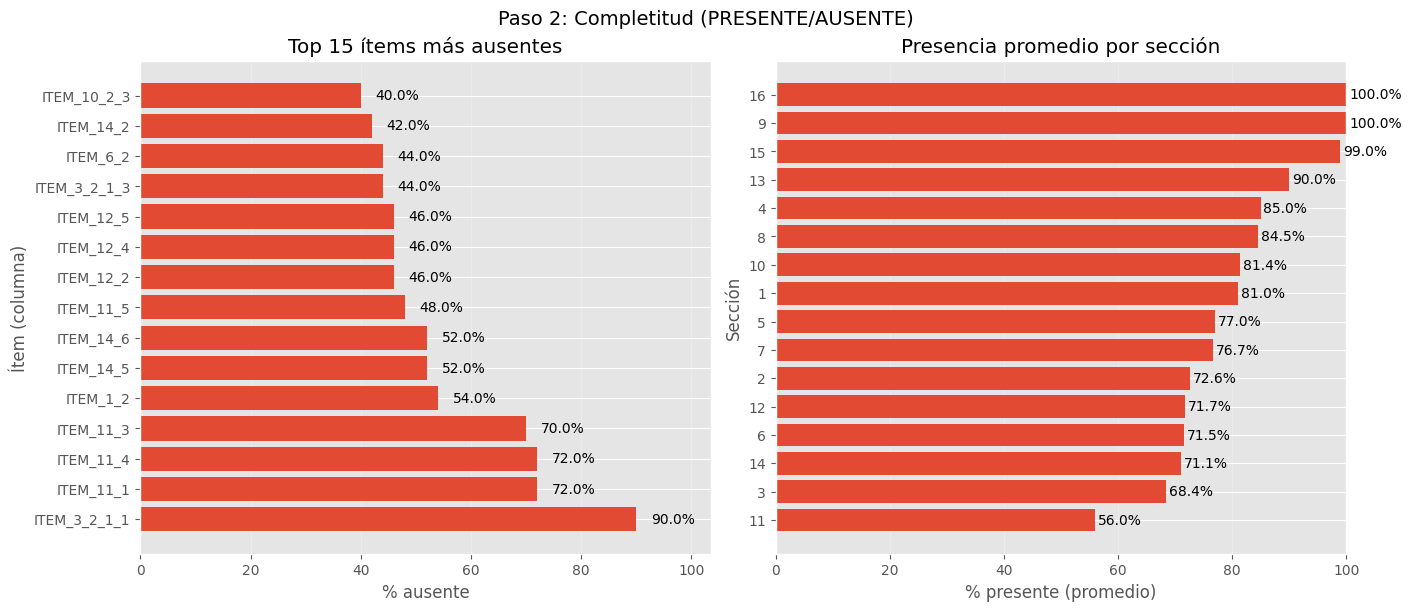

In [42]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
fig.suptitle("Paso 2: Completitud (PRESENTE/AUSENTE)", fontsize=14)

# 1) Top 15 ítems más ausentes
ax = axes[0]
plot_top = top15_ausentes.sort_values("porc_presente")  # menor presente = más ausente
bars = ax.barh(plot_top.index.astype(str), plot_top["porc_ausente"])
ax.set_title("Top 15 ítems más ausentes")
ax.set_xlabel("% ausente")
ax.set_ylabel("Ítem (columna)")
ax.grid(True, axis="x", alpha=0.25)

xmax = plot_top["porc_ausente"].max() if len(plot_top) else 0
pad = max(0.03 * xmax, 0.2) if xmax else 0.2
ax.set_xlim(0, xmax * 1.15 if xmax else 1)

for b in bars:
    w = b.get_width()
    ax.text(w + pad, b.get_y() + b.get_height()/2, f"{w:.1f}%", va="center")

# 2) Presencia promedio por sección
ax = axes[1]
sec_plot = tabla_seccion_presence.sort_values("porc_presente_prom")
bars = ax.barh(sec_plot["seccion"].astype(str), sec_plot["porc_presente_prom"])
ax.set_title("Presencia promedio por sección")
ax.set_xlabel("% presente (promedio)")
ax.set_ylabel("Sección")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", alpha=0.25)

for b in bars:
    w = b.get_width()
    ax.text(w + 0.5, b.get_y() + b.get_height()/2, f"{w:.1f}%", va="center")

plt.show()

In [15]:
# % PRESENTE por ITEM
item_presence = (df[item_cols] == "PRESENTE").mean().sort_values(ascending=True)

tabla_item_presence = item_presence.to_frame("prop_presente")
tabla_item_presence["porc_presente"] = (tabla_item_presence["prop_presente"] * 100).round(1)
tabla_item_presence["porc_ausente"] = (100 - tabla_item_presence["porc_presente"]).round(1)

top15_ausentes = tabla_item_presence.head(15)

tabla_item_presence

,prop_presente,porc_presente,porc_ausente
ITEM_3_2_1_1,0.10,10.0,90.0
ITEM_11_1,0.28,28.0,72.0
ITEM_11_4,0.28,28.0,72.0
ITEM_11_3,0.30,30.0,70.0
ITEM_1_2,0.46,46.0,54.0
...,...,...,...
ITEM_9_0,1.00,100.0,0.0
ITEM_9_1,1.00,100.0,0.0
ITEM_10_0,1.00,100.0,0.0
ITEM_12_0,1.00,100.0,0.0


In [16]:
top15_ausentes

,prop_presente,porc_presente,porc_ausente
ITEM_3_2_1_1,0.10,10.0,90.0
ITEM_11_1,0.28,28.0,72.0
ITEM_11_4,0.28,28.0,72.0
ITEM_11_3,0.30,30.0,70.0
ITEM_1_2,0.46,46.0,54.0
ITEM_14_5,0.48,48.0,52.0
ITEM_14_6,0.48,48.0,52.0
ITEM_11_5,0.52,52.0,48.0
ITEM_12_2,0.54,54.0,46.0
ITEM_12_4,0.54,54.0,46.0


In [17]:
import re

def section_of_item(col):
    m = re.match(r"ITEM_(\d+)_", col)
    return int(m.group(1)) if m else None

item_to_section = {c: section_of_item(c) for c in item_cols}

sec_rows = []
for sec in sorted(set(item_to_section.values())):
    cols_sec = [c for c,s in item_to_section.items() if s == sec]
    sec_rows.append({
        "seccion": sec,
        "n_items": len(cols_sec),
        "porc_presente_prom": float(((df[cols_sec] == "PRESENTE").mean(axis=1)).mean() * 100)
    })

tabla_seccion_presence = pd.DataFrame(sec_rows).sort_values("porc_presente_prom")
tabla_seccion_presence["porc_presente_prom"] = tabla_seccion_presence["porc_presente_prom"].round(1)

tabla_seccion_presence

,seccion,n_items,porc_presente_prom
10,11,6,56.0
2,3,5,68.4
13,14,7,71.1
5,6,4,71.5
11,12,6,71.7
1,2,7,72.6
6,7,3,76.7
4,5,4,77.0
0,1,6,81.0
9,10,7,81.4


In [56]:
df["COMPLETITUD_FDS"] = (df[item_cols] == "PRESENTE").mean(axis=1) * 100

tabla_completitud_stats = df["COMPLETITUD_FDS"].describe().to_frame("valor")
tabla_completitud_stats.loc["IQR"] = (
    df["COMPLETITUD_FDS"].quantile(0.75) - df["COMPLETITUD_FDS"].quantile(0.25)
)
tabla_completitud_stats = tabla_completitud_stats.round(2)

tabla_completitud_stats

,valor
count,50.00
mean,76.76
std,18.62
min,47.89
25%,59.15
50%,85.92
75%,91.55
max,100.00
IQR,32.39


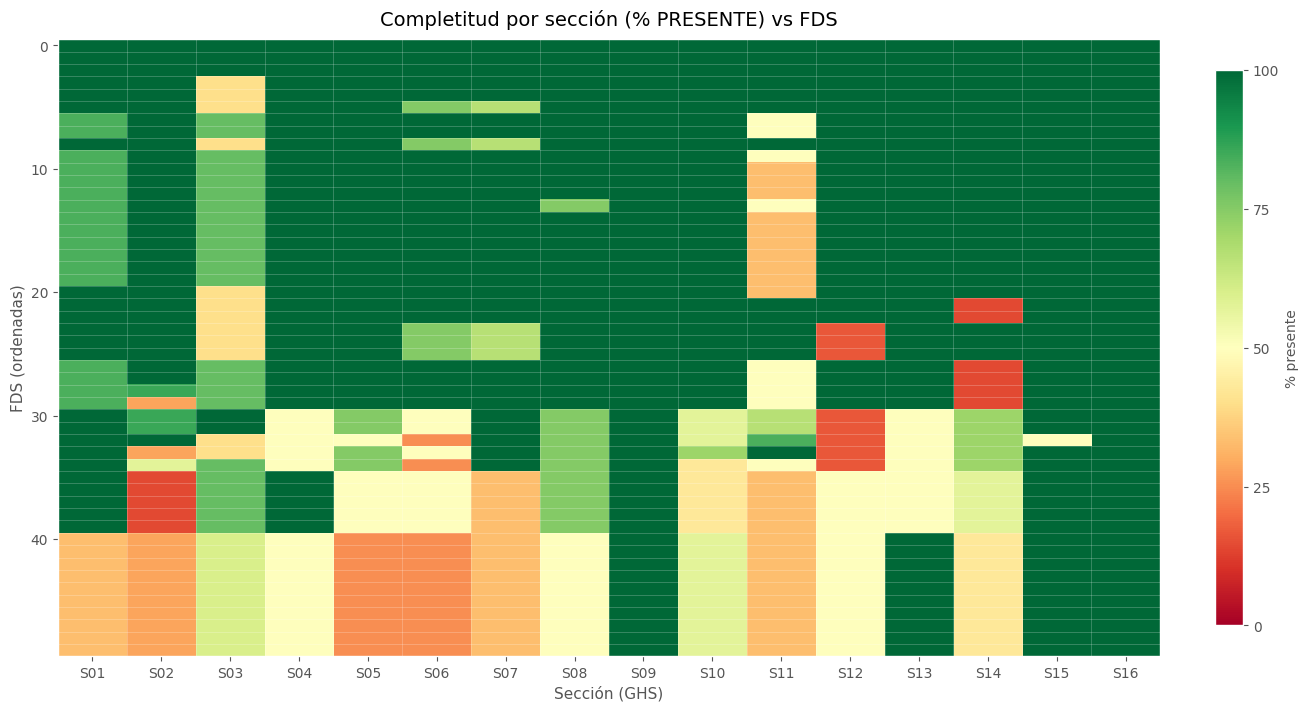

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# --- 1) Matriz FDS x Sección (% presente) ---
secciones = sorted({s for s in item_to_section.values() if s is not None})

mat = pd.DataFrame(index=df.index, columns=secciones, dtype=float)
for sec in secciones:
    cols_sec = [c for c, s in item_to_section.items() if s == sec]
    mat[sec] = df[cols_sec].eq("PRESENTE").mean(axis=1) * 100

mat.columns = [f"S{c:02d}" for c in mat.columns]  # S01..S16

# --- 2) Ordenar FDS ---
if "COMPLETITUD_FDS" in df.columns:
    order = df["COMPLETITUD_FDS"].sort_values(ascending=False).index
elif "SCORE_GLOBAL_0_100" in df.columns:
    order = df["SCORE_GLOBAL_0_100"].sort_values(ascending=False).index
else:
    order = df.index

mat_ord = mat.loc[order]

# Etiquetas Y (ID si existe)
ylabels = df.loc[order, "ID"].astype(str).values if "ID" in df.columns else mat_ord.index.astype(str).values

# --- 3) Heatmap "presentación" ---
fig, ax = plt.subplots(figsize=(13, 7), constrained_layout=True)

im = ax.imshow(
    mat_ord.values,
    aspect="auto",
    vmin=0, vmax=100,
    cmap="RdYlGn",          # 0=rojo (ausente), 100=verde (presente)
    interpolation="nearest"
)

ax.set_title("Completitud por sección (% PRESENTE) vs FDS", fontsize=14, pad=10)
ax.set_xlabel("Sección (GHS)", fontsize=11)
ax.set_ylabel("FDS (ordenadas)", fontsize=11)

# X: secciones
ax.set_xticks(np.arange(mat_ord.shape[1]))
ax.set_xticklabels(mat_ord.columns, fontsize=10)

# Y: mostrar solo cada k etiqueta
n = mat_ord.shape[0]
step = max(n // 12, 1)
yticks = np.arange(0, n, step)


# Grid sutil
ax.set_xticks(np.arange(-.5, mat_ord.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, mat_ord.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6, alpha=0.35)
ax.tick_params(which="minor", bottom=False, left=False)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("% presente", fontsize=10)
cbar.set_ticks([0, 25, 50, 75, 100])

ax.grid(visible=False, which="major")
ax.grid(visible=True, which="minor", color="white", linewidth=0.6, alpha=0.25)

plt.show()

# Exportación para presentación:
# fig.savefig("heatmap_completitud_RdYlGn.png", dpi=300, bbox_inches="tight")

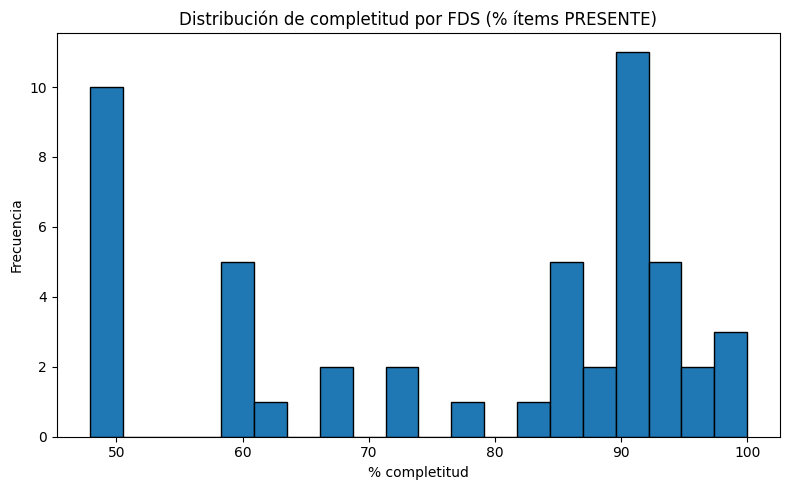

In [57]:
ax = df["COMPLETITUD_FDS"].plot(kind="hist", bins=20, edgecolor="black", figsize=(8,5))
ax.set_title("Distribución de completitud por FDS (% ítems PRESENTE)")
ax.set_xlabel("% completitud")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

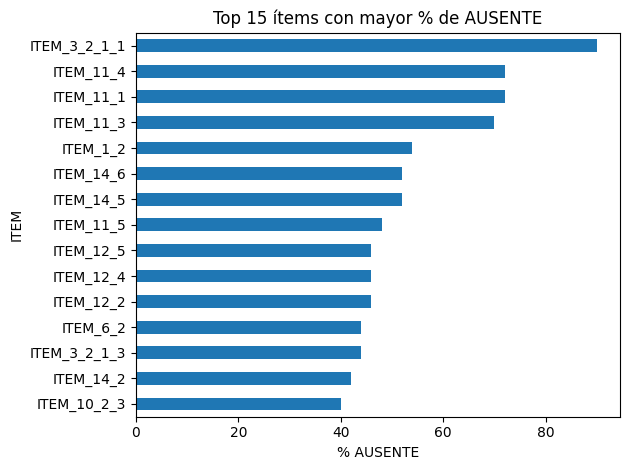

In [58]:
top15 = top15_ausentes.sort_values("porc_ausente", ascending=True)

ax = top15["porc_ausente"].plot(kind="barh")
ax.set_title("Top 15 ítems con mayor % de AUSENTE")
ax.set_xlabel("% AUSENTE")
ax.set_ylabel("ITEM")
plt.tight_layout()
plt.show()

## __Paso 3: Calidad (NO_CONFIABLE / CONFI_RESTR / CONFIABLE)__

In [59]:
# Frecuencias globales de calidad (todas las celdas CALIDAD_)
global_counts = df[cal_cols].stack().value_counts(dropna=False)
tabla_global_calidad = pd.DataFrame({
    "conteo": global_counts,
    "porcentaje": (global_counts / global_counts.sum() * 100).round(1)
})
tabla_global_calidad

,conteo,porcentaje
CONFIABLE,1756,49.5
NO_CONFIABLE,1068,30.1
CONFI_RESTR,726,20.5


In [60]:
# Tabla: por cada CALIDAD_x, proporción de cada categoría
tabla_calidad_por_item = (
    df[cal_cols]
    .apply(lambda s: s.value_counts(normalize=True))
    .T
    .fillna(0)
)

# Asegurar orden de columnas
for c in ["NO_CONFIABLE", "CONFI_RESTR", "CONFIABLE"]:
    if c not in tabla_calidad_por_item.columns:
        tabla_calidad_por_item[c] = 0.0
tabla_calidad_por_item = tabla_calidad_por_item[["NO_CONFIABLE","CONFI_RESTR","CONFIABLE"]]

tabla_calidad_por_item = (tabla_calidad_por_item * 100).round(1)

# Top 15 ítems con mayor % NO_CONFIABLE
top15_no_confiable = tabla_calidad_por_item.sort_values("NO_CONFIABLE", ascending=False).head(15)

tabla_calidad_por_item.head(), top15_no_confiable

(             NO_CONFIABLE  CONFI_RESTR  CONFIABLE
 CALIDAD_1_0          12.0          4.0       84.0
 CALIDAD_1_1          56.0         14.0       30.0
 CALIDAD_1_2          50.0         28.0       22.0
 CALIDAD_1_3           0.0         18.0       82.0
 CALIDAD_1_4           0.0         20.0       80.0,
                  NO_CONFIABLE  CONFI_RESTR  CONFIABLE
 CALIDAD_3_2_1_1          78.0         10.0       12.0
 CALIDAD_11_1             76.0         14.0       10.0
 CALIDAD_11_3             74.0          0.0       26.0
 CALIDAD_4_2              72.0          2.0       26.0
 CALIDAD_11_4             68.0          8.0       24.0
 CALIDAD_15_1             64.0         34.0        2.0
 CALIDAD_4_3              62.0         12.0       26.0
 CALIDAD_8_2              60.0         26.0       14.0
 CALIDAD_1_1              56.0         14.0       30.0
 CALIDAD_6_2              52.0         24.0       24.0
 CALIDAD_14_6             52.0          0.0       48.0
 CALIDAD_11_5             50.0   

In [61]:
# Recalcular por seguridad (si ya existen, se sobreescriben)
map_q = {"NO_CONFIABLE": 0, "CONFI_RESTR": 1, "CONFIABLE": 2}
q_num = df[cal_cols].replace(map_q)

df["SCORE_GLOBAL_0_2"] = q_num.mean(axis=1)
df["SCORE_GLOBAL_0_100"] = df["SCORE_GLOBAL_0_2"] * 50

tabla_score_global_stats = df["SCORE_GLOBAL_0_100"].describe().to_frame("valor")
tabla_score_global_stats.loc["IQR"] = (
    df["SCORE_GLOBAL_0_100"].quantile(0.75) - df["SCORE_GLOBAL_0_100"].quantile(0.25)
)
tabla_score_global_stats = tabla_score_global_stats.round(2)

tabla_score_global_stats

,valor
count,50.00
unique,23.00
top,31.69
freq,10.00
IQR,42.61


In [62]:
import re

def section_of_cal(col):
    m = re.match(r"CALIDAD_(\d+)_", col)
    return int(m.group(1)) if m else None

cal_to_section = {c: section_of_cal(c) for c in cal_cols}
sections = sorted(set(cal_to_section.values()))

for sec in sections:
    cols_sec = [c for c,s in cal_to_section.items() if s == sec]
    df[f"SCORE_SEC_{sec}_0_100"] = (df[cols_sec].replace(map_q).mean(axis=1) * 50)

tabla_seccion_score = pd.DataFrame({
    "seccion": sections,
    "n_calidades": [sum(1 for c in cal_cols if section_of_cal(c) == sec) for sec in sections],
    "score_prom_0_100": [df[f"SCORE_SEC_{sec}_0_100"].mean() for sec in sections],
    "score_mediana_0_100": [df[f"SCORE_SEC_{sec}_0_100"].median() for sec in sections],
}).sort_values("score_prom_0_100")

tabla_seccion_score[["score_prom_0_100","score_mediana_0_100"]] = tabla_seccion_score[["score_prom_0_100","score_mediana_0_100"]].round(2)

tabla_seccion_score

,seccion,n_calidades,score_prom_0_100,score_mediana_0_100
11,12,6,44.50,58.33
10,11,6,46.50,37.50
14,15,2,49.50,50.00
9,10,7,53.86,57.14
5,6,4,55.00,50.00
7,8,4,55.00,50.00
13,14,7,58.86,28.57
2,3,5,59.20,60.00
3,4,4,62.25,50.00
12,13,2,65.00,75.00


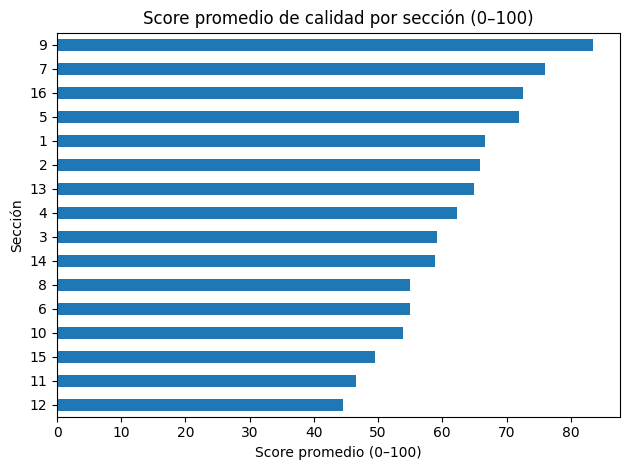

In [63]:
tmp = tabla_seccion_score.sort_values("score_prom_0_100", ascending=True).set_index("seccion")["score_prom_0_100"]

ax = tmp.plot(kind="barh")
ax.set_title("Score promedio de calidad por sección (0–100)")
ax.set_xlabel("Score promedio (0–100)")
ax.set_ylabel("Sección")
plt.tight_layout()
plt.show()

In [64]:
tabla_por_uso = df.groupby("USO")["SCORE_GLOBAL_0_100"].agg(["count","mean","median","std"]).round(2).sort_values("mean")
tabla_por_fab = df.groupby("FABRICANTE")["SCORE_GLOBAL_0_100"].agg(["count","mean","median","std"]).round(2).sort_values("mean")

tabla_por_uso, tabla_por_fab

(            count       mean     median    std
 USO                                           
 DOMESTICA      25  48.197183  47.887324  17.57
 INDUSTRIAL     25  71.183099  74.647887  21.52,
             count       mean     median   std
 FABRICANTE                                   
 F08             5  28.169014  28.169014  0.00
 F06            10  31.690141  31.690141  0.00
 F02             5  45.774648  47.887324  3.76
 F03            10  69.295775  70.070423  5.55
 F07             5  69.859155  71.830986  2.70
 F04             5  74.225352  71.830986  5.35
 F01             5  85.633803  85.211268  2.31
 F05             5  91.267606  90.140845  1.54)

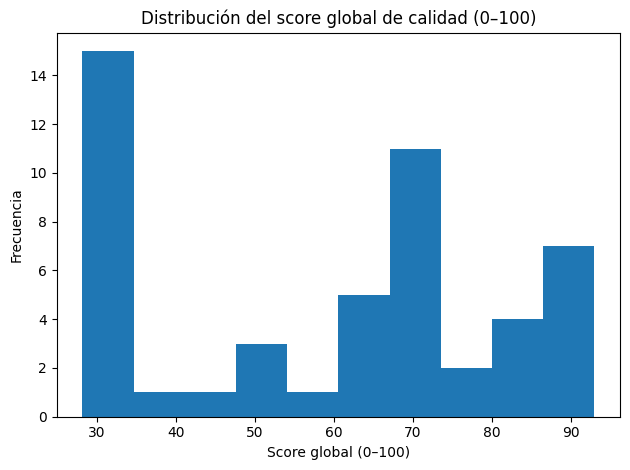

In [65]:
ax = df["SCORE_GLOBAL_0_100"].plot(kind="hist", bins=10)
ax.set_title("Distribución del score global de calidad (0–100)")
ax.set_xlabel("Score global (0–100)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

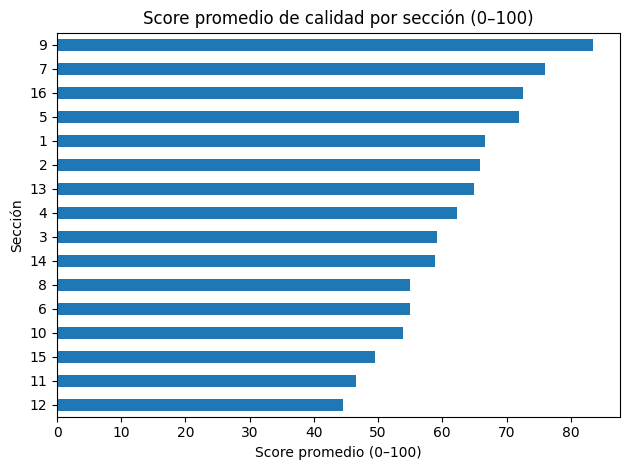

In [66]:
tmp = tabla_seccion_score.sort_values("score_prom_0_100", ascending=True).set_index("seccion")["score_prom_0_100"]

ax = tmp.plot(kind="barh")
ax.set_title("Score promedio de calidad por sección (0–100)")
ax.set_xlabel("Score promedio (0–100)")
ax.set_ylabel("Sección")
plt.tight_layout()
plt.show()

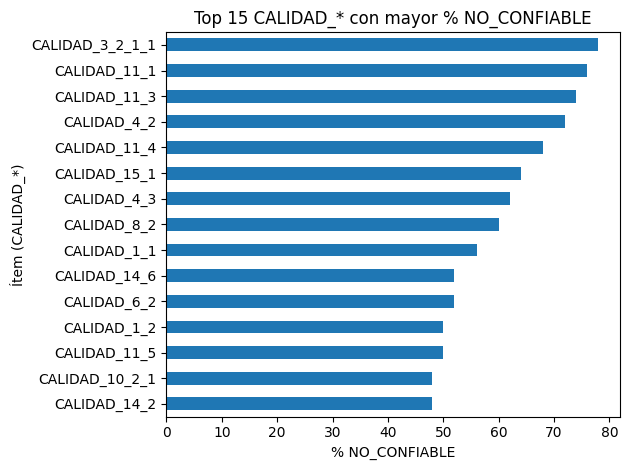

In [67]:
tmp2 = top15_no_confiable.sort_values("NO_CONFIABLE", ascending=True)["NO_CONFIABLE"]

ax = tmp2.plot(kind="barh")
ax.set_title("Top 15 CALIDAD_* con mayor % NO_CONFIABLE")
ax.set_xlabel("% NO_CONFIABLE")
ax.set_ylabel("Ítem (CALIDAD_*)")
plt.tight_layout()
plt.show()

## __Paso 4A — Correlación entre secciones (Spearman)__

In [68]:
# Columnas de score por sección (0-100) creadas en Paso 3
sec_score_cols = [c for c in df.columns if c.startswith("SCORE_SEC_") and c.endswith("_0_100")]

corr_sec = df[sec_score_cols].corr(method="spearman").round(2)
corr_sec

,SCORE_SEC_1_0_100,SCORE_SEC_2_0_100,SCORE_SEC_3_0_100,SCORE_SEC_4_0_100,SCORE_SEC_5_0_100,SCORE_SEC_6_0_100,SCORE_SEC_7_0_100,SCORE_SEC_8_0_100,SCORE_SEC_9_0_100,SCORE_SEC_10_0_100,SCORE_SEC_11_0_100,SCORE_SEC_12_0_100,SCORE_SEC_13_0_100,SCORE_SEC_14_0_100,SCORE_SEC_15_0_100,SCORE_SEC_16_0_100
SCORE_SEC_1_0_100,1.00,0.38,0.32,-0.04,0.30,0.14,0.30,0.47,0.11,0.00,0.32,-0.02,-0.18,0.03,-0.22,0.80
SCORE_SEC_2_0_100,0.38,1.00,0.72,0.75,0.81,0.83,0.69,0.87,0.77,0.76,0.79,0.58,0.60,0.57,0.37,0.77
SCORE_SEC_3_0_100,0.32,0.72,1.00,0.41,0.63,0.60,0.50,0.70,0.51,0.42,0.57,0.30,0.31,0.48,0.15,0.62
SCORE_SEC_4_0_100,-0.04,0.75,0.41,1.00,0.54,0.89,0.55,0.75,0.62,0.76,0.84,0.57,0.79,0.34,0.29,0.46
SCORE_SEC_5_0_100,0.30,0.81,0.63,0.54,1.00,0.76,0.65,0.71,0.84,0.84,0.51,0.68,0.57,0.62,0.66,0.69
SCORE_SEC_6_0_100,0.14,0.83,0.60,0.89,0.76,1.00,0.75,0.83,0.73,0.80,0.86,0.66,0.72,0.44,0.42,0.64
SCORE_SEC_7_0_100,0.30,0.69,0.50,0.55,0.65,0.75,1.00,0.68,0.73,0.60,0.70,0.53,0.31,0.29,0.56,0.59
SCORE_SEC_8_0_100,0.47,0.87,0.70,0.75,0.71,0.83,0.68,1.00,0.69,0.71,0.88,0.40,0.53,0.33,0.19,0.80
SCORE_SEC_9_0_100,0.11,0.77,0.51,0.62,0.84,0.73,0.73,0.69,1.00,0.88,0.60,0.69,0.69,0.66,0.74,0.48
SCORE_SEC_10_0_100,0.00,0.76,0.42,0.76,0.84,0.80,0.60,0.71,0.88,1.00,0.61,0.66,0.76,0.55,0.67,0.43


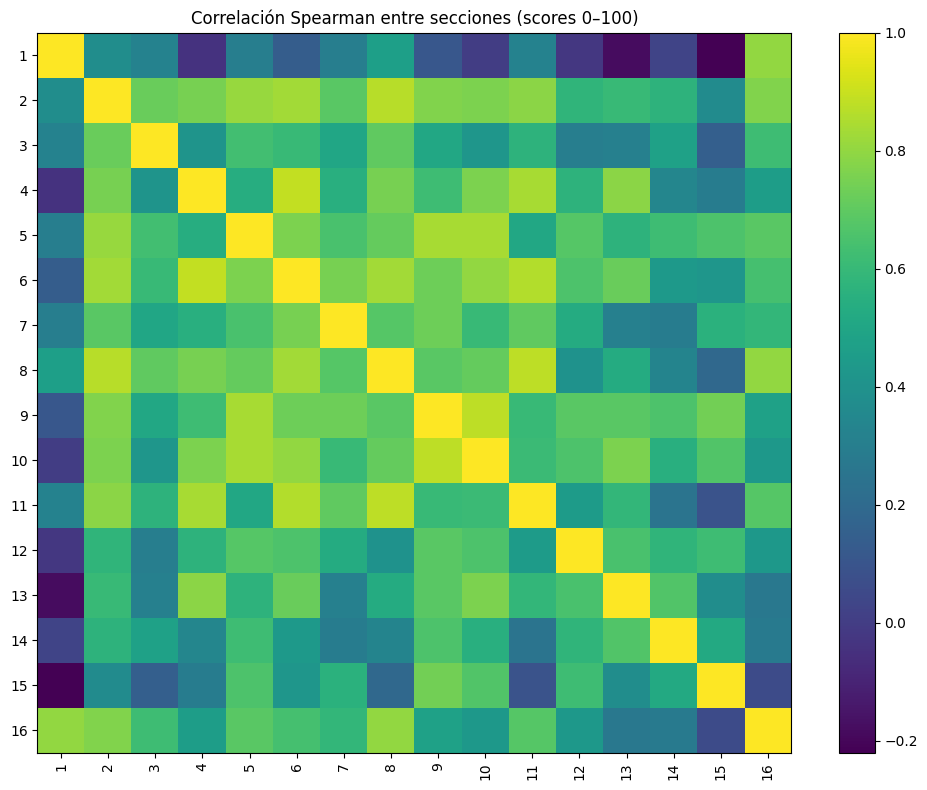

In [69]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_sec.values, aspect="auto")

ax.set_title("Correlación Spearman entre secciones (scores 0–100)")
ax.set_xticks(range(len(corr_sec.columns)))
ax.set_yticks(range(len(corr_sec.index)))

ax.set_xticklabels([c.replace("SCORE_SEC_","").replace("_0_100","") for c in corr_sec.columns], rotation=90)
ax.set_yticklabels([c.replace("SCORE_SEC_","").replace("_0_100","") for c in corr_sec.index])

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [70]:
def brecha(df, col_alta, col_baja, q_alta=0.75, q_baja=0.25):
    thr_alta = df[col_alta].quantile(q_alta)
    thr_baja = df[col_baja].quantile(q_baja)

    mask = (df[col_alta] >= thr_alta) & (df[col_baja] <= thr_baja)
    out = df.loc[mask, ["ID","FABRICANTE","USO","ELABORADA", col_alta, col_baja, "SCORE_GLOBAL_0_100"]].copy()
    out = out.sort_values([col_alta, col_baja], ascending=[False, True])

    return thr_alta, thr_baja, out

In [71]:

col2 = "SCORE_SEC_2_0_100"
col8 = "SCORE_SEC_8_0_100"

thr2, thr8, brecha_2_8 = brecha(df, col2, col8)

thr2, thr8, brecha_2_8.head(20), brecha_2_8.shape

(100.0,
 37.5,
 Empty DataFrame
 Columns: [ID, FABRICANTE, USO, ELABORADA, SCORE_SEC_2_0_100, SCORE_SEC_8_0_100, SCORE_GLOBAL_0_100]
 Index: [],
 (0, 7))

In [72]:

col11 = "SCORE_SEC_11_0_100"
thr2b, thr11, brecha_2_11 = brecha(df, col2, col11)

thr2b, thr11, brecha_2_11.head(20), brecha_2_11.shape

(100.0,
 25.0,
 Empty DataFrame
 Columns: [ID, FABRICANTE, USO, ELABORADA, SCORE_SEC_2_0_100, SCORE_SEC_11_0_100, SCORE_GLOBAL_0_100]
 Index: [],
 (0, 7))

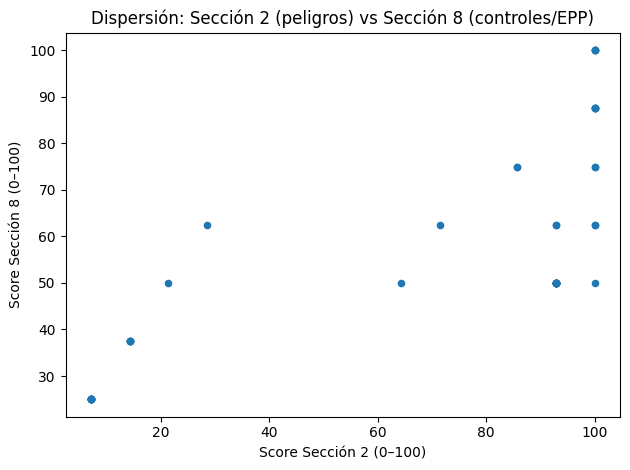

In [73]:
ax = df.plot(kind="scatter", x=col2, y=col8)
ax.set_title("Dispersión: Sección 2 (peligros) vs Sección 8 (controles/EPP)")
ax.set_xlabel("Score Sección 2 (0–100)")
ax.set_ylabel("Score Sección 8 (0–100)")
plt.tight_layout()
plt.show()

## __Paso 5__

In [74]:
# 1) Eventos de AUSENCIA (completitud)
ausente = (df[item_cols] != "PRESENTE")
ausente.columns = [f"AUSENTE_{c}" for c in ausente.columns]

# 2) Eventos de NO_CONFIABLE (calidad)
no_conf = (df[cal_cols] == "NO_CONFIABLE")
no_conf.columns = [f"NO_CONFIABLE_{c}" for c in no_conf.columns]

# 3) Matriz transaccional (FDS x eventos)
X = pd.concat([ausente, no_conf], axis=1).astype(bool)

X.shape, X.sum().sort_values(ascending=False).head(10)

((50, 142),
 AUSENTE_ITEM_3_2_1_1            45
 NO_CONFIABLE_CALIDAD_3_2_1_1    39
 NO_CONFIABLE_CALIDAD_11_1       38
 NO_CONFIABLE_CALIDAD_11_3       37
 AUSENTE_ITEM_11_1               36
 NO_CONFIABLE_CALIDAD_4_2        36
 AUSENTE_ITEM_11_4               36
 AUSENTE_ITEM_11_3               35
 NO_CONFIABLE_CALIDAD_11_4       34
 NO_CONFIABLE_CALIDAD_15_1       32
 dtype: int64)

In [75]:
tabla_uso_global = (
    df.groupby("USO")["SCORE_GLOBAL_0_100"]
      .agg(n="count", media="mean", mediana="median", sd="std", p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
      .round(2)
      .sort_values("media")
)
tabla_uso_global

,n,media,mediana,sd,p25,p75
USO,,,,,,
DOMESTICA,25,48.197183,47.887324,17.57,31.69,66.20
INDUSTRIAL,25,71.183099,74.647887,21.52,71.83,88.03


/var/folders/t3/dd_m7b7x3nx7hlsr6x5zfm980000gn/T/ipykernel_24236/1298830466.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


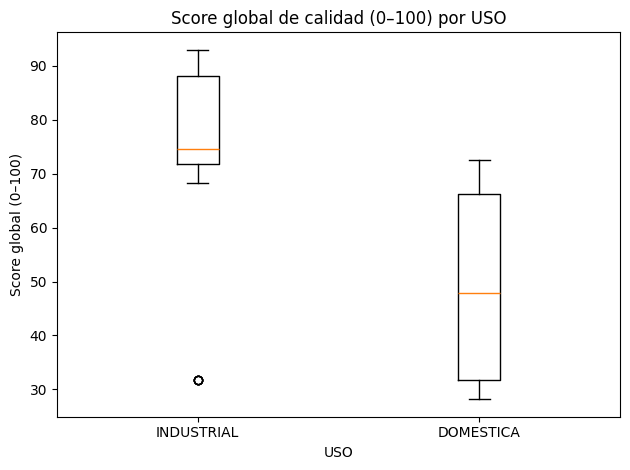

In [76]:
data = [df.loc[df["USO"]==u, "SCORE_GLOBAL_0_100"].dropna().values for u in df["USO"].dropna().unique()]
labels = [u for u in df["USO"].dropna().unique()]

fig, ax = plt.subplots()
ax.boxplot(data, labels=labels)
ax.set_title("Score global de calidad (0–100) por USO")
ax.set_xlabel("USO")
ax.set_ylabel("Score global (0–100)")
plt.tight_layout()
plt.show()

In [77]:
tabla_fab_global = (
    df.groupby("FABRICANTE")["SCORE_GLOBAL_0_100"]
      .agg(n="count", media="mean", mediana="median", sd="std", p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
      .round(2)
      .sort_values("media")
)
tabla_fab_global

,n,media,mediana,sd,p25,p75
FABRICANTE,,,,,,
F08,5,28.169014,28.169014,0.00,28.17,28.17
F06,10,31.690141,31.690141,0.00,31.69,31.69
F02,5,45.774648,47.887324,3.76,43.66,48.59
F03,10,69.295775,70.070423,5.55,65.67,73.06
F07,5,69.859155,71.830986,2.70,66.90,71.83
F04,5,74.225352,71.830986,5.35,71.83,71.83
F01,5,85.633803,85.211268,2.31,83.80,88.03
F05,5,91.267606,90.140845,1.54,90.14,92.96


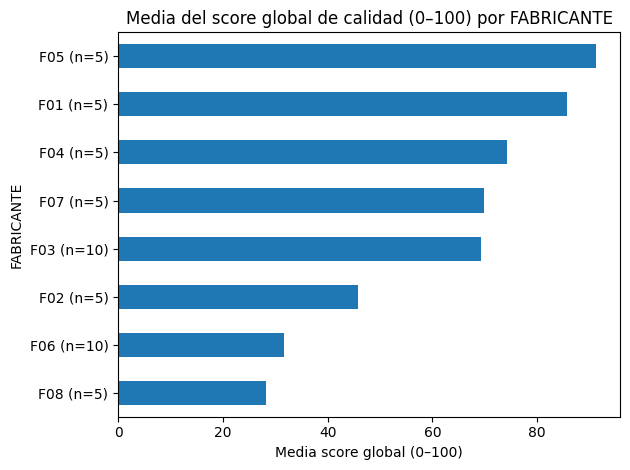

In [78]:
tmp = tabla_fab_global.copy()
labels = [f"{idx} (n={int(tmp.loc[idx,'n'])})" for idx in tmp.index]

ax = pd.Series(tmp["media"].values, index=labels).plot(kind="barh")
ax.set_title("Media del score global de calidad (0–100) por FABRICANTE")
ax.set_xlabel("Media score global (0–100)")
ax.set_ylabel("FABRICANTE")
plt.tight_layout()
plt.show()

In [79]:
sec_score_cols = [c for c in df.columns if c.startswith("SCORE_SEC_") and c.endswith("_0_100")]

tabla_uso_secciones = df.groupby("USO")[sec_score_cols].mean().round(2)
tabla_uso_secciones

,SCORE_SEC_1_0_100,SCORE_SEC_2_0_100,SCORE_SEC_3_0_100,SCORE_SEC_4_0_100,SCORE_SEC_5_0_100,SCORE_SEC_6_0_100,SCORE_SEC_7_0_100,SCORE_SEC_8_0_100,SCORE_SEC_9_0_100,SCORE_SEC_10_0_100,SCORE_SEC_11_0_100,SCORE_SEC_12_0_100,SCORE_SEC_13_0_100,SCORE_SEC_14_0_100,SCORE_SEC_15_0_100,SCORE_SEC_16_0_100
USO,,,,,,,,,,,,,,,,
DOMESTICA,66.333333,52.285714,52.0,51.0,59.5,42.5,69.333333,46.5,73.0,44.857143,35.0,32.0,45.0,32.0,38.0,70.0
INDUSTRIAL,67.0,79.428571,66.4,73.5,84.5,67.5,82.666667,63.5,94.0,62.857143,58.0,57.0,85.0,85.714286,61.0,75.0


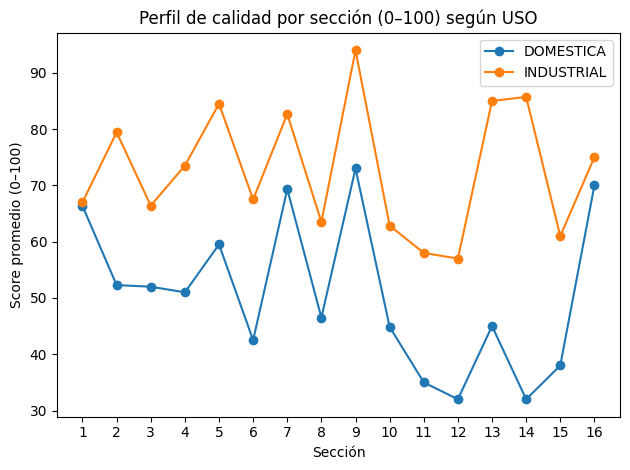

In [80]:
# Preparar ejes por número de sección
secs = [int(c.replace("SCORE_SEC_","").replace("_0_100","")) for c in sec_score_cols]
order = np.argsort(secs)

secs_sorted = np.array(secs)[order]
cols_sorted = np.array(sec_score_cols)[order]

fig, ax = plt.subplots()
for uso, g in df.groupby("USO"):
    y = g[cols_sorted].mean().values
    ax.plot(secs_sorted, y, marker="o", label=uso)

ax.set_title("Perfil de calidad por sección (0–100) según USO")
ax.set_xlabel("Sección")
ax.set_ylabel("Score promedio (0–100)")
ax.set_xticks(secs_sorted)
ax.legend()
plt.tight_layout()
plt.show()

In [81]:
tabla_fab_secciones = df.groupby("FABRICANTE")[sec_score_cols].mean().round(2)
tabla_fab_secciones

,SCORE_SEC_1_0_100,SCORE_SEC_2_0_100,SCORE_SEC_3_0_100,SCORE_SEC_4_0_100,SCORE_SEC_5_0_100,SCORE_SEC_6_0_100,SCORE_SEC_7_0_100,SCORE_SEC_8_0_100,SCORE_SEC_9_0_100,SCORE_SEC_10_0_100,SCORE_SEC_11_0_100,SCORE_SEC_12_0_100,SCORE_SEC_13_0_100,SCORE_SEC_14_0_100,SCORE_SEC_15_0_100,SCORE_SEC_16_0_100
FABRICANTE,,,,,,,,,,,,,,,,
F01,58.333333,100.0,100.0,100.0,100.0,90.0,80.0,87.5,100.0,85.714286,91.666667,46.666667,100.0,100.0,50.0,75.0
F02,83.333333,70.0,66.0,50.0,27.5,37.5,96.666667,60.0,75.0,31.428571,55.0,0.0,0.0,12.857143,0.0,75.0
F03,68.333333,86.428571,55.0,58.75,98.75,66.25,100.0,57.5,97.5,69.285714,40.0,62.5,75.0,65.714286,75.0,75.0
F04,65.0,94.285714,76.0,60.0,100.0,57.5,100.0,57.5,100.0,62.857143,33.333333,73.333333,75.0,100.0,80.0,75.0
F05,100.0,100.0,64.0,100.0,100.0,100.0,100.0,92.5,100.0,68.571429,100.0,85.0,100.0,100.0,50.0,100.0
F06,41.666667,7.142857,30.0,50.0,25.0,25.0,33.333333,25.0,75.0,35.714286,25.0,16.666667,75.0,28.571429,50.0,50.0
F07,56.666667,92.857143,66.0,70.0,95.0,70.0,100.0,50.0,90.0,51.428571,46.666667,81.666667,75.0,65.714286,65.0,75.0
F08,83.333333,14.285714,50.0,25.0,50.0,12.5,16.666667,37.5,25.0,28.571429,8.333333,0.0,0.0,21.428571,0.0,75.0


## __Paso 7__

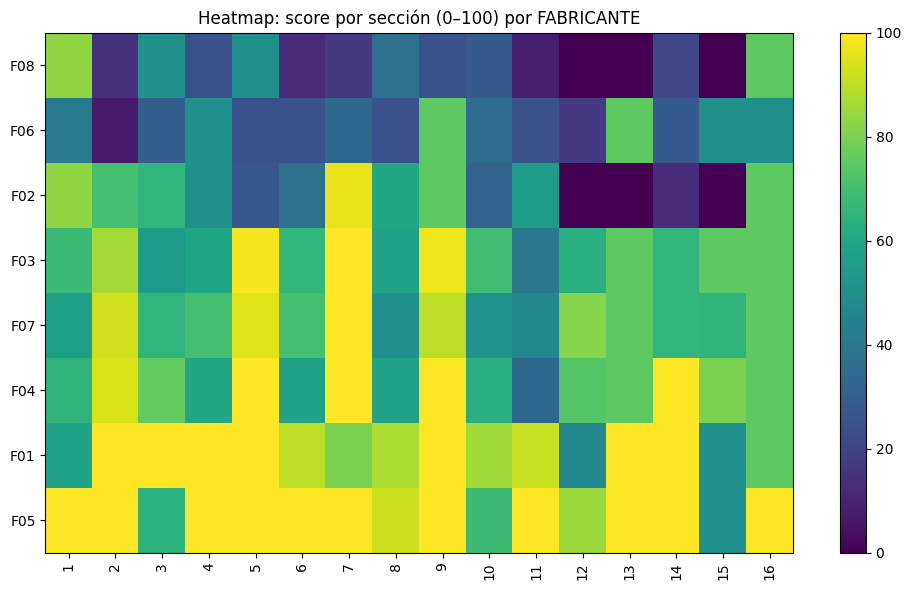

,SCORE_SEC_1_0_100,SCORE_SEC_2_0_100,SCORE_SEC_3_0_100,SCORE_SEC_4_0_100,SCORE_SEC_5_0_100,SCORE_SEC_6_0_100,SCORE_SEC_7_0_100,SCORE_SEC_8_0_100,SCORE_SEC_9_0_100,SCORE_SEC_10_0_100,SCORE_SEC_11_0_100,SCORE_SEC_12_0_100,SCORE_SEC_13_0_100,SCORE_SEC_14_0_100,SCORE_SEC_15_0_100,SCORE_SEC_16_0_100
FABRICANTE,,,,,,,,,,,,,,,,
F08,83.333333,14.285714,50.0,25.00,50.00,12.50,16.666667,37.5,25.0,28.571429,8.333333,0.000000,0.0,21.428571,0.0,75.0
F06,41.666667,7.142857,30.0,50.00,25.00,25.00,33.333333,25.0,75.0,35.714286,25.000000,16.666667,75.0,28.571429,50.0,50.0
F02,83.333333,70.000000,66.0,50.00,27.50,37.50,96.666667,60.0,75.0,31.428571,55.000000,0.000000,0.0,12.857143,0.0,75.0
F03,68.333333,86.428571,55.0,58.75,98.75,66.25,100.000000,57.5,97.5,69.285714,40.000000,62.500000,75.0,65.714286,75.0,75.0
F07,56.666667,92.857143,66.0,70.00,95.00,70.00,100.000000,50.0,90.0,51.428571,46.666667,81.666667,75.0,65.714286,65.0,75.0
F04,65.000000,94.285714,76.0,60.00,100.00,57.50,100.000000,57.5,100.0,62.857143,33.333333,73.333333,75.0,100.000000,80.0,75.0
F01,58.333333,100.000000,100.0,100.00,100.00,90.00,80.000000,87.5,100.0,85.714286,91.666667,46.666667,100.0,100.000000,50.0,75.0
F05,100.000000,100.000000,64.0,100.00,100.00,100.00,100.000000,92.5,100.0,68.571429,100.000000,85.000000,100.0,100.000000,50.0,100.0


In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- HEATMAP FABRICANTE x SECCIÓN (robusto a dtype=object) ---

# 1) Tabla base: media por sección según fabricante
sec_score_cols = [c for c in df.columns if c.startswith("SCORE_SEC_") and c.endswith("_0_100")]
tabla_fab_secciones = df.groupby("FABRICANTE")[sec_score_cols].mean()

# 2) Ordenar fabricantes por score global medio (si existe); si no, por nombre
if "SCORE_GLOBAL_0_100" in df.columns:
    tabla_fab_global = (
        df.groupby("FABRICANTE")["SCORE_GLOBAL_0_100"]
          .mean()
          .sort_values()
          .to_frame("media")
    )
    fab_order = tabla_fab_global.index.tolist()
else:
    fab_order = sorted(tabla_fab_secciones.index.tolist())

mat = tabla_fab_secciones.loc[fab_order].copy()

# 3) Ordenar columnas por número de sección (SCORE_SEC_{n}_0_100)
secs = [int(c.replace("SCORE_SEC_", "").replace("_0_100", "")) for c in mat.columns]
order = np.argsort(secs)
mat = mat.iloc[:, order]

# 4) Convertir TODO a numérico (evita error dtype object) y tratar NaN
mat_num = mat.apply(pd.to_numeric, errors="coerce")

# Si hay NaN (por ejemplo, secciones sin datos en algún fabricante), imputar con media de la columna
# (alternativa: .fillna(0) si prefieres)
mat_num = mat_num.fillna(mat_num.mean())

# 5) Graficar heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(mat_num.values, aspect="auto", vmin=0, vmax=100)

ax.set_title("Heatmap: score por sección (0–100) por FABRICANTE")
ax.set_yticks(range(mat_num.shape[0]))
ax.set_yticklabels(mat_num.index)

ax.set_xticks(range(mat_num.shape[1]))
ax.set_xticklabels(
    [c.replace("SCORE_SEC_", "").replace("_0_100", "") for c in mat_num.columns],
    rotation=90
)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# (Opcional) Mostrar la matriz numérica usada
mat_num

In [83]:
tabla_anio = (
    df.groupby("ANIO")["SCORE_GLOBAL_0_100"]
      .agg(n="count", media="mean", mediana="median", sd="std")
      .round(2)
      .sort_index()
)
tabla_anio

,n,media,mediana,sd
ANIO,,,,
2016,5,91.267606,90.140845,1.54
2018,23,50.61237,47.887324,19.65
2019,10,53.943662,64.788732,22.86
2020,12,68.720657,71.830986,18.43


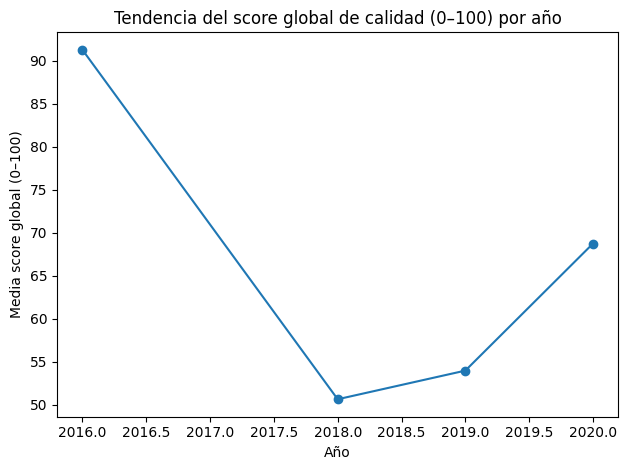

In [84]:
tmp = df.groupby("ANIO")["SCORE_GLOBAL_0_100"].mean().sort_index()

ax = tmp.plot(kind="line", marker="o")
ax.set_title("Tendencia del score global de calidad (0–100) por año")
ax.set_xlabel("Año")
ax.set_ylabel("Media score global (0–100)")
plt.tight_layout()
plt.show()

## __Paso 7__

In [85]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Completitud por sección (desde ITEM_) ---
item_cols = [c for c in df.columns if c.startswith("ITEM_")]
cal_cols  = [c for c in df.columns if c.startswith("CALIDAD_")]

def section_of_item(col):
    m = re.match(r"ITEM_(\d+)_", col)
    return int(m.group(1)) if m else None

item_to_section = {c: section_of_item(c) for c in item_cols}
sections = sorted(set(item_to_section.values()))

sec_complet = {}
sec_n_items = {}
for sec in sections:
    cols_sec = [c for c,s in item_to_section.items() if s == sec]
    sec_n_items[sec] = len(cols_sec)
    sec_complet[sec] = float(((df[cols_sec] == "PRESENTE").mean(axis=1)).mean() * 100)

tabla_complet_seccion = pd.DataFrame({
    "seccion": sections,
    "n_items": [sec_n_items[s] for s in sections],
    "completitud_prom_0_100": [sec_complet[s] for s in sections],
})

# --- 2) Calidad por sección (ya calculada como SCORE_SEC_{sec}_0_100) ---
sec_score_cols = [c for c in df.columns if c.startswith("SCORE_SEC_") and c.endswith("_0_100")]

def section_of_score(col):
    m = re.match(r"SCORE_SEC_(\d+)_0_100", col)
    return int(m.group(1)) if m else None

sec_quality = {}
for c in sec_score_cols:
    s = section_of_score(c)
    if s is not None:
        sec_quality[s] = float(df[c].mean())

tabla_calidad_seccion = pd.DataFrame({
    "seccion": sorted(sec_quality.keys()),
    "calidad_prom_0_100": [sec_quality[s] for s in sorted(sec_quality.keys())]
})

# --- 3) Unir y crear índice combinado ---
tabla_seccion_ejecutiva = tabla_complet_seccion.merge(tabla_calidad_seccion, on="seccion", how="left")

# Índice combinado simple (ajustable):
# - 50% completitud + 50% calidad
tabla_seccion_ejecutiva["indice_combinado_0_100"] = (
    0.5 * tabla_seccion_ejecutiva["completitud_prom_0_100"] +
    0.5 * tabla_seccion_ejecutiva["calidad_prom_0_100"]
)

tabla_seccion_ejecutiva = tabla_seccion_ejecutiva.round(2).sort_values("indice_combinado_0_100")
tabla_seccion_ejecutiva

,seccion,n_items,completitud_prom_0_100,calidad_prom_0_100,indice_combinado_0_100
10,11,6,56.00,46.50,51.25
11,12,6,71.67,44.50,58.08
5,6,4,71.50,55.00,63.25
2,3,5,68.40,59.20,63.80
13,14,7,71.14,58.86,65.00
9,10,7,81.43,53.86,67.64
1,2,7,72.57,65.86,69.21
7,8,4,84.50,55.00,69.75
3,4,4,85.00,62.25,73.62
0,1,6,81.00,66.67,73.83


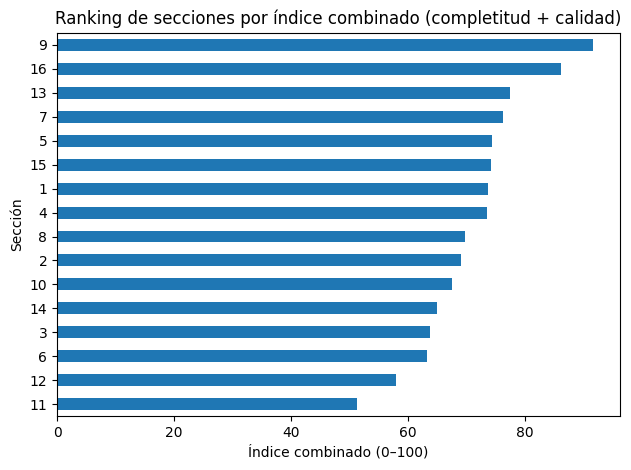

In [86]:
tmp = tabla_seccion_ejecutiva.set_index("seccion")["indice_combinado_0_100"].sort_values()

ax = tmp.plot(kind="barh")
ax.set_title("Ranking de secciones por índice combinado (completitud + calidad)")
ax.set_xlabel("Índice combinado (0–100)")
ax.set_ylabel("Sección")
plt.tight_layout()
plt.show()

In [87]:
# Frecuencia de AUSENTE por ITEM
freq_ausente = (df[item_cols] != "PRESENTE").mean() * 100
freq_ausente = freq_ausente.to_frame("porc_ausente").round(1)

# Frecuencia de NO_CONFIABLE por CALIDAD
freq_no_conf = (df[cal_cols] == "NO_CONFIABLE").mean() * 100
freq_no_conf = freq_no_conf.to_frame("porc_no_confiable").round(1)

# Top 15 por cada una
top15_aus = freq_ausente.sort_values("porc_ausente", ascending=False).head(15)
top15_nc  = freq_no_conf.sort_values("porc_no_confiable", ascending=False).head(15)

top15_aus, top15_nc

(              porc_ausente
 ITEM_3_2_1_1          90.0
 ITEM_11_4             72.0
 ITEM_11_1             72.0
 ITEM_11_3             70.0
 ITEM_1_2              54.0
 ITEM_14_6             52.0
 ITEM_14_5             52.0
 ITEM_11_5             48.0
 ITEM_12_2             46.0
 ITEM_12_4             46.0
 ITEM_12_5             46.0
 ITEM_6_2              44.0
 ITEM_3_2_1_3          44.0
 ITEM_14_2             42.0
 ITEM_8_2              40.0,
                  porc_no_confiable
 CALIDAD_3_2_1_1               78.0
 CALIDAD_11_1                  76.0
 CALIDAD_11_3                  74.0
 CALIDAD_4_2                   72.0
 CALIDAD_11_4                  68.0
 CALIDAD_15_1                  64.0
 CALIDAD_4_3                   62.0
 CALIDAD_8_2                   60.0
 CALIDAD_1_1                   56.0
 CALIDAD_6_2                   52.0
 CALIDAD_14_6                  52.0
 CALIDAD_11_5                  50.0
 CALIDAD_1_2                   50.0
 CALIDAD_14_2                  48.0
 CALIDAD_10

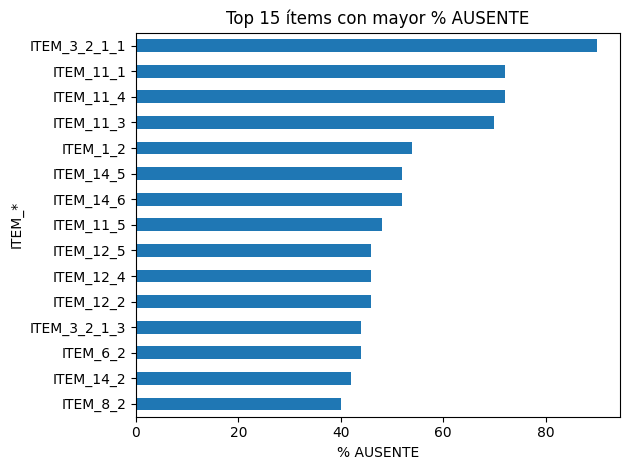

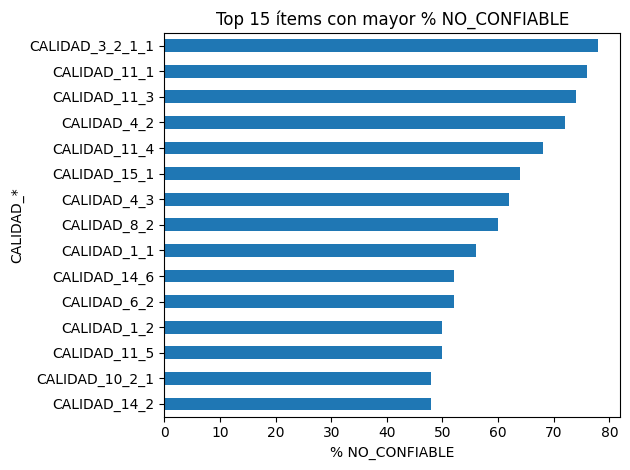

In [88]:
ax = top15_aus.sort_values("porc_ausente")["porc_ausente"].plot(kind="barh")
ax.set_title("Top 15 ítems con mayor % AUSENTE")
ax.set_xlabel("% AUSENTE")
ax.set_ylabel("ITEM_*")
plt.tight_layout()
plt.show()

ax = top15_nc.sort_values("porc_no_confiable")["porc_no_confiable"].plot(kind="barh")
ax.set_title("Top 15 ítems con mayor % NO_CONFIABLE")
ax.set_xlabel("% NO_CONFIABLE")
ax.set_ylabel("CALIDAD_*")
plt.tight_layout()
plt.show()

In [89]:
# Variabilidad por sección (SD) para ver heterogeneidad
sec_sd = {}
for c in sec_score_cols:
    s = section_of_score(c)
    if s is not None:
        sec_sd[s] = float(df[c].std())

tabla_var_seccion = pd.DataFrame({
    "seccion": sorted(sec_sd.keys()),
    "sd_calidad_0_100": [sec_sd[s] for s in sorted(sec_sd.keys())]
}).round(2)

hallazgos = tabla_seccion_ejecutiva.merge(tabla_var_seccion, on="seccion", how="left")
hallazgos = hallazgos.sort_values("indice_combinado_0_100").head(8)  # top 8 secciones más críticas
hallazgos

,seccion,n_items,completitud_prom_0_100,calidad_prom_0_100,indice_combinado_0_100,sd_calidad_0_100
0,11,6,56.00,46.50,51.25,28.63
1,12,6,71.67,44.50,58.08,35.38
2,6,4,71.50,55.00,63.25,30.62
3,3,5,68.40,59.20,63.80,22.30
4,14,7,71.14,58.86,65.00,40.29
5,10,7,81.43,53.86,67.64,21.22
6,2,7,72.57,65.86,69.21,40.21
7,8,4,84.50,55.00,69.75,23.15


In [90]:
tabla_uso = (
    df.groupby("USO")["SCORE_GLOBAL_0_100"]
      .agg(n="count", media="mean", mediana="median", sd="std",
           p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
      .round(2)
)
tabla_uso

,n,media,mediana,sd,p25,p75
USO,,,,,,
DOMESTICA,25,48.197183,47.887324,17.57,31.69,66.20
INDUSTRIAL,25,71.183099,74.647887,21.52,71.83,88.03


In [92]:
from scipy.stats import kruskal

grupos = [g["SCORE_GLOBAL_0_100"].dropna().values for _, g in df.groupby("USO")]

H, p = kruskal(*grupos)

k = df["USO"].nunique()
n = df["SCORE_GLOBAL_0_100"].notna().sum()
epsilon2 = (H - k + 1) / (n - k)  # tamaño de efecto

tabla_kw_uso = pd.DataFrame({
    "H": [round(float(H), 4)],
    "p_value": [round(float(p), 6)],
    "epsilon2": [round(float(epsilon2), 4)],
    "k_grupos": [int(k)],
    "n_total": [int(n)]
})
tabla_kw_uso

AttributeError: 'float' object has no attribute 'dtype'

/var/folders/t3/dd_m7b7x3nx7hlsr6x5zfm980000gn/T/ipykernel_24236/3392410391.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


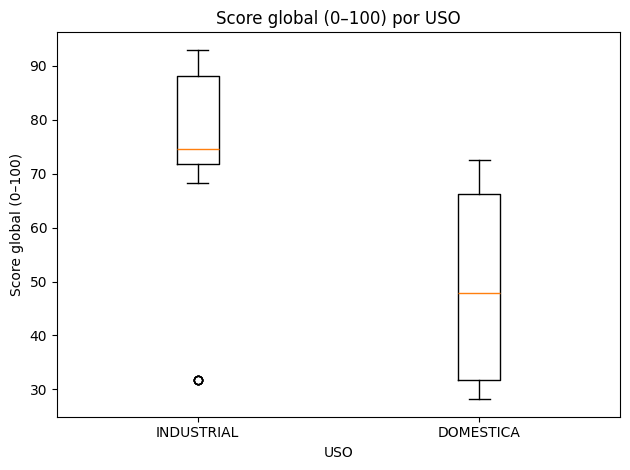

In [93]:
labels = [u for u in df["USO"].dropna().unique()]
data = [df.loc[df["USO"]==u, "SCORE_GLOBAL_0_100"].dropna().values for u in labels]

fig, ax = plt.subplots()
ax.boxplot(data, labels=labels)
ax.set_title("Score global (0–100) por USO")
ax.set_xlabel("USO")
ax.set_ylabel("Score global (0–100)")
plt.tight_layout()
plt.show()

In [94]:
tabla_fab = (
    df.groupby("FABRICANTE")["SCORE_GLOBAL_0_100"]
      .agg(n="count", media="mean", mediana="median", sd="std",
           p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
      .round(2)
      .sort_values("media")
)
tabla_fab

,n,media,mediana,sd,p25,p75
FABRICANTE,,,,,,
F08,5,28.169014,28.169014,0.00,28.17,28.17
F06,10,31.690141,31.690141,0.00,31.69,31.69
F02,5,45.774648,47.887324,3.76,43.66,48.59
F03,10,69.295775,70.070423,5.55,65.67,73.06
F07,5,69.859155,71.830986,2.70,66.90,71.83
F04,5,74.225352,71.830986,5.35,71.83,71.83
F01,5,85.633803,85.211268,2.31,83.80,88.03
F05,5,91.267606,90.140845,1.54,90.14,92.96


In [95]:
grupos_f = [g["SCORE_GLOBAL_0_100"].dropna().values for _, g in df.groupby("FABRICANTE")]

Hf, pf = kruskal(*grupos_f)

kf = df["FABRICANTE"].nunique()
nf = df["SCORE_GLOBAL_0_100"].notna().sum()
epsilon2_f = (Hf - kf + 1) / (nf - kf)

tabla_kw_fab = pd.DataFrame({
    "H": [round(float(Hf), 4)],
    "p_value": [round(float(pf), 6)],
    "epsilon2": [round(float(epsilon2_f), 4)],
    "k_grupos": [int(kf)],
    "n_total": [int(nf)]
})
tabla_kw_fab

AttributeError: 'float' object has no attribute 'dtype'